In [1]:
import cv2 as cv
import numpy as np
from matplotlib import pyplot as plt

In [2]:
img_rgb = cv.imread('/Users/miguelcamargorojas/Documents/UP/PDI - Ene-may25/images/rubberwhale1.png')[:, :, ::-1]

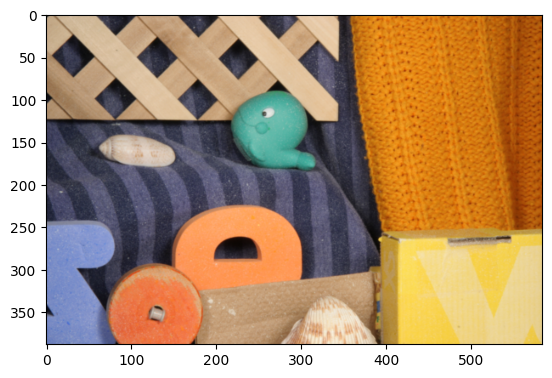

In [3]:
plt.imshow(img_rgb)
plt.show()

In [6]:
# Origen 2 Destino
cv.COLOR_RGB2HSV

41

In [8]:
img_rgb.shape

(388, 584, 3)

In [7]:
# rgb2gray()MATLAB
# cvtColor() OpenCV 
cv.cvtColor(img_rgb, cv.COLOR_RGB2GRAY)

array([[ 13,  14,  20, ..., 105, 112, 113],
       [ 16,  19,  33, ..., 117, 117, 117],
       [ 19,  33,  85, ..., 114, 118, 117],
       ...,
       [126, 126, 127, ..., 194, 200, 203],
       [126, 126, 127, ..., 192, 196, 203],
       [124, 125, 128, ..., 193, 194, 202]], shape=(388, 584), dtype=uint8)

In [10]:
# RGB a HSV
img_hsv = cv.cvtColor(img_rgb, cv.COLOR_RGB2HSV)

In [11]:
img_hsv.shape

(388, 584, 3)

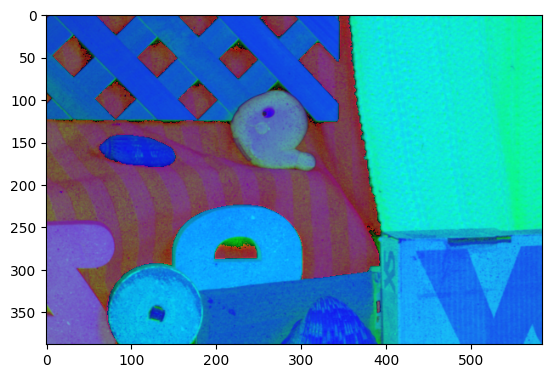

In [12]:
plt.imshow(img_hsv)
plt.show()

In [ ]:
h, s, v = cv.split(img_hsv)

In [14]:
h.max()

np.uint8(179)

In [15]:
s.max()

np.uint8(255)

In [16]:
v.max()

np.uint8(255)

---
Ecualizando HSV / HSL

1) Convertir de RGB a HSV
2) Separar los canales de HSV
3) Ecualizar el canal V -> V-eq
4) Unimos HSV-eq
5) Cvt HSV a RGB
6) (opcional) Mostrar

In [18]:
# 3)
v_eq = cv.equalizeHist(v)

In [20]:
# 4)
img_hsv_veq = cv.merge((h, s, v_eq))

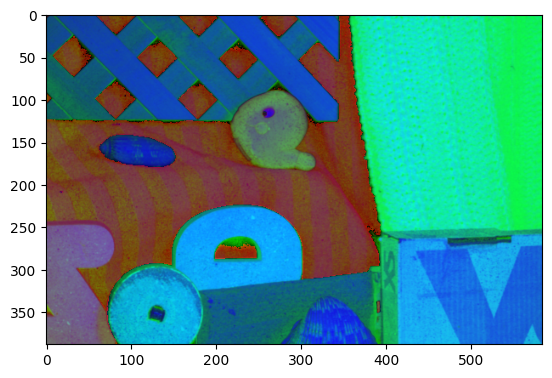

In [21]:
plt.imshow(img_hsv_veq)
plt.show()

In [22]:
# 5)
img_rgb_eq = cv.cvtColor(img_hsv_veq, cv.COLOR_HSV2RGB)

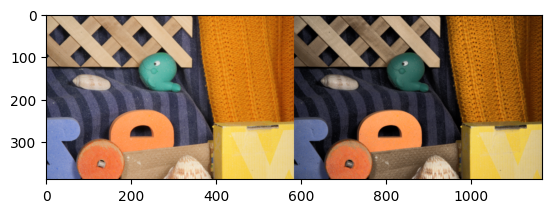

In [23]:
# 6)
plt.imshow(np.hstack((img_rgb, img_rgb_eq)))
plt.show()

---
Ecualizando YCbCr

1) Convertir de RGB a YCbCr
2) Separar los canales de YCbCr
3) Ecualizar el canal Y -> Y-eq
4) Unimos Y-eqCbCr
5) Cvt YCbCr a RGB
6) (opcional) Mostrar

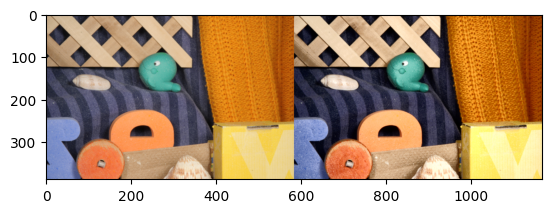

In [24]:
img_ycrcb = cv.cvtColor(img_rgb, cv.COLOR_RGB2YCrCb)
y, cr, cb = cv.split(img_ycrcb)
y_eq = cv.equalizeHist(y)
img_ycrcb_eq = cv.merge((y_eq, cr, cb))
img_ycrb2rgb_eq = cv.cvtColor(img_ycrcb_eq, cv.COLOR_YCrCb2RGB)
plt.imshow(np.hstack((img_rgb, img_ycrb2rgb_eq)))
plt.show()